In [1]:
import matplotlib.pyplot as plt
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore', message='.*Glyph.*missing from font.*')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime

In [3]:
import glob
import os

### Read stats 

In [4]:
main_dir = '/pscratch/sd/p/paccini/temp/hackathon/updated_environmental_variables/'
mcs_stats = 'df_filtered_mcs_track_ids/'
# main_dir = '/Users/pacc275/local_documents/hackathon/updated_environmental_variables/' #local
# --- Define main components ---
TRACK_MODELS = ['um', 'icon', 'scream', 'ifs', 'nicam', 'obs', 'obs_v7'] 
VARIABLES = ['prw', 'rh500', 'rh850', 'q500', 'q850', 'omega500', 'omega850',  'lShear', 'dShear','free_rh'] #'w850', 'w500',
CRITERIA = ['all', 'min2']

In [5]:
# --- Path Configuration ---

# 1. Map your track model name (e.g., 'obs') to the 
#    corresponding environmental data directory (e.g., 'era5')
ENV_MODEL_DIR_MAP = {
    'um': 'UM_all',
    'icon': 'ICON_all',
    'scream': 'SCREAM_all',
    'ifs': 'IFS_all',
    'nicam': 'NICAM_all',
    'obs_v7': 'ERA5_IMERGv7_all' ,
    'obs': 'era5'  # Key insight: 'obs' tracks map to 'era5' env data
}

# 2. Define the path pattern for each variable.
#    'type': 'dir' (read the whole dir as parquet) or 
#            'glob' (find a single file using a wildcard '*')
VAR_PATH_PATTERNS = {
    # Default patterns used by most models (um, scream, etc.)
    'default': {
        'prw':      {'type': 'dir', 'pattern': 'prw/'},
        'rh500':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_500hPa.parquet'},
        'rh850':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_850hPa.parquet'},
        'free_rh':    {'type': 'glob', 'pattern': 'hur/mcs_env_hur_*_hur_avg850-*-500hPa.parquet'},
        'q500':     {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_500hPa.parquet'},
        'q850':     {'type': 'glob', 'pattern': 'hus/mcs_env_hus_*_hus_850hPa.parquet'},
        'omega500': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_500hPa.parquet'},
        'omega850': {'type': 'glob', 'pattern': 'omega/mcs_env_omega_*_omega_850hPa.parquet'},
        # 'w500':     {'type': 'glob', 'pattern': 'wa/mcs_env_wa_*_wa_500hPa.parquet'},
        # 'w850':     {'type': 'glob', 'pattern': 'wa/mcs_env_wa_*_wa_850hPa.parquet'},
        'lShear':   {'type': 'dir', 'pattern': 'low_shear_magnitude_975hPa-800hPa/'},
        'dShear':   {'type': 'dir', 'pattern': 'deep_shear_magnitude_850hPa-400hPa/'},
    },
    # Overrides for the 'obs' (era5) model
    'obs': {
        'q500':     {'type': 'dir', 'pattern': 'q_500mb/'},
         'rh500':  {'type': 'dir', 'pattern': 'rh_500mb/'},
        'q850':     {'type': 'dir', 'pattern': 'q_850mb/'},
         'rh850':  {'type': 'dir', 'pattern': 'rh_850mb/'},
          'prw': {'type': 'dir', 'pattern':'TCWV/'},
        'rh500':  {'type': 'dir', 'pattern': 'rh_500mb/'},
        'omega500':     {'type': 'dir', 'pattern': 'w_500mb/'},
        'omega850':     {'type': 'dir', 'pattern': 'w_850mb/'},
        # 'lShear':   {'type': 'dir', 'pattern': 'shear_mag_0to2km/'},
        # 'dShear':   {'type': 'dir', 'pattern': 'shear_mag_0to10km/'},
    }
}

# --- New Path-Finding Function ---

def get_env_path(base_out_dir, model_name, var_name):
    """
    Finds the correct file path for a given model and variable,
    handling inconsistent names and date stamps.
    
    'model_name' should be from TRACK_MODELS (e.g., 'um', 'obs')
    """
    
    # 1. Get the top-level directory name (e.g., 'UM_all' or 'era5')
    if model_name not in ENV_MODEL_DIR_MAP:
        raise KeyError(f"Model '{model_name}' not defined in ENV_MODEL_DIR_MAP.")
    model_dir = ENV_MODEL_DIR_MAP[model_name]
    
    # 2. Get the path pattern rule for this variable
    # Check for a model-specific override first (e.g., for 'obs')
    if model_name in VAR_PATH_PATTERNS and var_name in VAR_PATH_PATTERNS[model_name]:
        rule = VAR_PATH_PATTERNS[model_name][var_name]
    # Otherwise, use the default rule
    elif var_name in VAR_PATH_PATTERNS['default']:
        rule = VAR_PATH_PATTERNS['default'][var_name]
    else:
        raise KeyError(f"Variable '{var_name}' not defined in VAR_PATH_PATTERNS.")
        
    pattern_type = rule['type']
    pattern = rule['pattern']
    
    # 3. Construct the full search path
    full_search_path = os.path.join(base_out_dir, model_dir, pattern)
    
    # 4. Find the file/directory
    if pattern_type == 'dir':
        # For 'dir' type, we just return the path as-is.
        return full_search_path
        
    elif pattern_type == 'glob':
        # For 'glob', we find all files matching the pattern
        search_results = glob.glob(full_search_path)
        
        if len(search_results) == 0:
            raise FileNotFoundError(f"No file found for {model_name}/{var_name}. "
                                    f"Searched: {full_search_path}")
        if len(search_results) > 1:
            # This is ambiguous, which is bad.
            raise FileNotFoundError(f"Multiple files found for {model_name}/{var_name}. "
                                     f"Searched: {full_search_path}. "
                                     f"Found: {search_results}")
        
        # Success! Return the one and only match.
        return search_results[0]

In [6]:
# --- Transformation Configuration ---
# Define all model/variable-specific unit conversions here

TRANSFORM_CONFIG = {
    'nicam': {
        'rh500': lambda df: df.assign(mean=df['mean'] * 100),
        'rh850': lambda df: df.assign(mean=df['mean'] * 100),
        'free_rh': lambda df: df.assign(mean=df['mean'] * 100),
    },
    'obs': {  # 'obs' is our alias for 'era5imergv6'
        'q500': lambda df: df.assign(mean=df['mean'] / 1000),
        'q850': lambda df: df.assign(mean=df['mean'] / 1000),
    },

}

In [7]:
# --- Load Environmental Data ---
raw_env_data = {}
for model in TRACK_MODELS: # Loop over our base track models
    raw_env_data[model] = {}
    for var in VARIABLES:
        try:
            # 1. Find the path (same as before)
            path = get_env_path(main_dir, model, var)
            
            # 2. Load the data
            df = pd.read_parquet(path)
            
            # 3. *** NEW: Apply Transformation ***
            # Get the specific transform function from our config
            # If no rule exists, it defaults to a function that does nothing (lambda x: x)
            transform_func = TRANSFORM_CONFIG.get(model, {}).get(var, lambda x: x)
            
            # Apply the function to the DataFrame
            df_transformed = transform_func(df)
            
            # 4. Store the standardized DataFrame
            raw_env_data[model][var] = df_transformed
        #     # Our function handles all the ugly logic!
        #     path = get_env_path(main_dir, model, var)
        #     raw_env_data[model][var] = pd.read_parquet(path)
        except Exception as e:
            # Catch errors from loading OR transforming
            print(f"Warning: Could not load env data for {model} - {var}. Error: {e}")
            raw_env_data[model][var] = None

# --- Load Track Data ---
raw_track_data = {}
for model in TRACK_MODELS:
    raw_track_data[model] = {}
    for crit in CRITERIA:
        try:
            crit_suffix = f'_{crit}' if crit != 'all' else ''
            # path = os.path.join(mcs_stats, f'df_trop_{model}{crit_suffix}.pkl')
            path = os.path.join(mcs_stats, f'with_circular_lffiltered_{model}{crit_suffix}_r2.pkl')
            raw_track_data[model][crit] = pd.read_pickle(path)
        except Exception as e:
            print(f"Warning: Could not load track data for {model} - {crit}. Error: {e}")
            raw_track_data[model][crit] = None

In [8]:
# --- Filtering environments ---
def get_filtered_df(df_main, df_tracks, lf_thresh=0.1,lf_var='total_land_fraction_track'):
    """
    Merges main data with track data data and filters by circular land fraction threshold.
    """
    # Safe Merge (Inner Join) on track_id to ensure data integrity
    # Adjust 'track_id' if your column names differ between dataframes
    merged_df = pd.merge( df_main, df_tracks[['track_id', 'total_total_rain',lf_var]], on='track_id', how='inner')
    
    # Filter by Land Fraction Threshold
    # Ensure it handles NaNs if necessary, though inner join usually drops non-matches
    final_df = merged_df[merged_df[lf_var] <= lf_thresh].copy()
    
    return final_df

def remove_longdurations(df_model, feature='duration_hours', p_high=0.9):
    if df_model is None:
        return None
    q_high = df_model[feature].quantile(p_high)
    df_filtered = df_model[(df_model[feature] <= q_high)].copy()
    return df_filtered

In [9]:
# --- Final processing loop  ---
processed_data = {}

for model in TRACK_MODELS:
    processed_data[model] = {}
    for crit in CRITERIA:
        base_track_df = raw_track_data[model].get(crit)
        
        if base_track_df is None:
            print(f"Skipping {model} - {crit}: Missing base track data.")
            continue
            
        long_removed_track_df = remove_longdurations(base_track_df)
        
        crit_key_base = crit
        crit_key_longremoved = f'{crit}_longremoved'
        
        processed_data[model][crit_key_base] = {}
        processed_data[model][crit_key_longremoved] = {}
        
        for var in VARIABLES:
            raw_env_df = raw_env_data[model].get(var)
            
            if raw_env_df is None:
                # This will now correctly skip missing 'era5' data
                continue 

            processed_data[model][crit_key_base][var] = get_filtered_df(
                raw_env_df, base_track_df
            )
            
            processed_data[model][crit_key_longremoved][var] = get_filtered_df(
                raw_env_df, long_removed_track_df
            )

print("Processing complete!")

Processing complete!


In [10]:
np.unique(processed_data['ifs']['all']['lShear'].isna().values)

array([False])

In [11]:
import tools_mcs_stats 

In [12]:
import importlib
importlib.reload(tools_mcs_stats)

<module 'tools_mcs_stats' from '/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py'>

### Distribution of variables at a given time (t = 0)

In [13]:
import seaborn as sns

In [14]:
# --- 1. Visual Style Configuration ---
MODEL_STYLES = {
    'scream': {'color': '#2ca02c', 'label': 'SCREAM', 'lw': 1.5 },
    'um':     {'color': 'salmon',  'label': 'UM', 'lw': 1.5 },
    'icon':   {'color': '#ff7f0e', 'label': 'ICON', 'lw': 1.5 },
    'ifs':    {'color': 'steelblue','label': 'IFS', 'lw': 1.5 },
    'nicam':  {'color': 'mediumpurple',  'label': 'NICAM', 'lw': 1.5 },
    'obs':    {'color': 'gray',    'label': 'ERA5-IMERGv6', 'lw': 2.8 }, 
    'obs_v7':    {'color': 'k',    'label': 'ERA5-IMERGv7', 'lw': 2.8 , }, 
}


### Choosing similar environments for conditional probability distributions

In [15]:
import mycolors as mycmap

In [16]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

In [19]:
import importlib
importlib.reload(tools_mcs_stats)


<module 'tools_mcs_stats' from '/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py'>

Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.25015671 -0.19432712 -0.16110544 -0.13577873 -0.11438525
 -0.09517717 -0.07461386 -0.05142473 -0.02015271  0.28470599]

=== Plotting omega distribution (top panel) ===
Total omega data points: 6513


/tmp/ipykernel_1960480/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


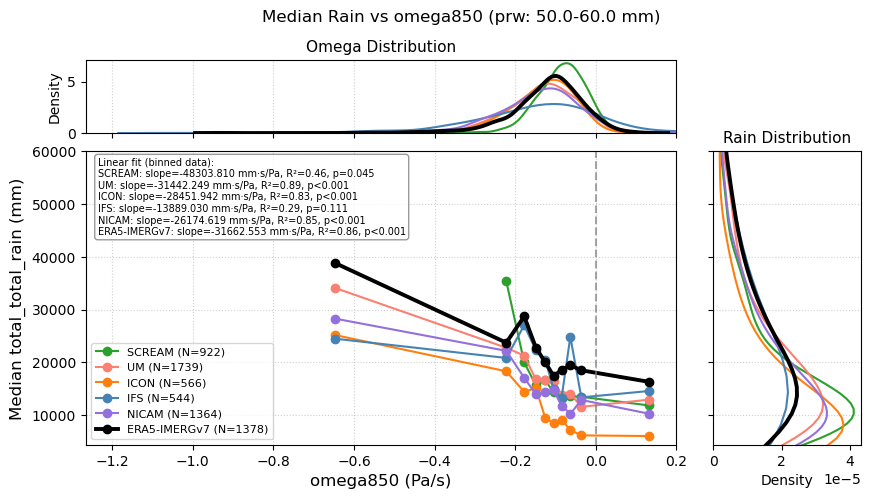

In [141]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [0, 0.1, 0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmax=0.2,
    figsize=(10, 5)
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2222 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2598: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


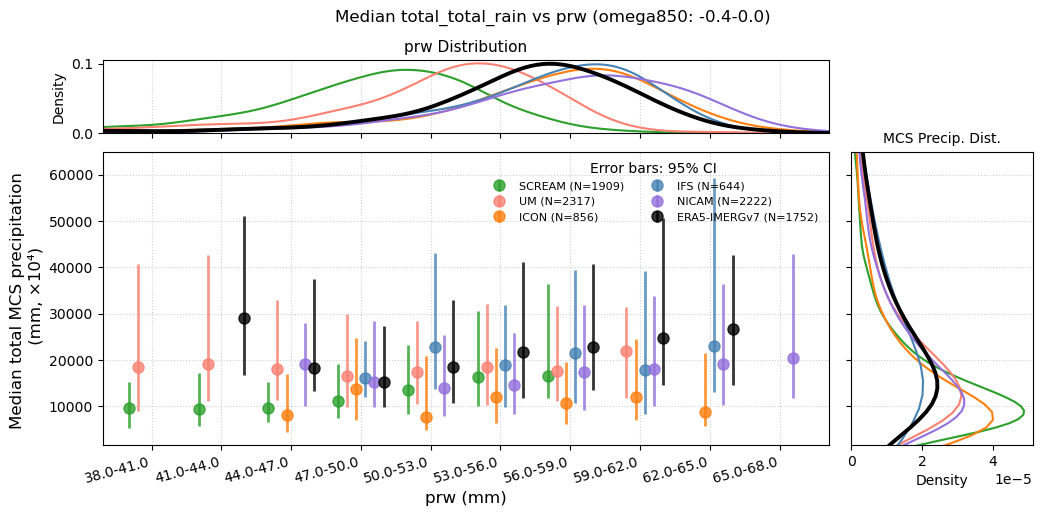

In [33]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='prw',
    bins=np.arange(38,70,3),
    constrain_var='omega850',
    manual_constrain_limits=(-.4,0),  # common omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=15, #xmin=7.5/1000,xmax=15.5/1000,
    xaxis_multiplier=1,  # Convert kg/kg to g/kg
    xaxis_units='mm',       # Show units
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2222 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2597: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


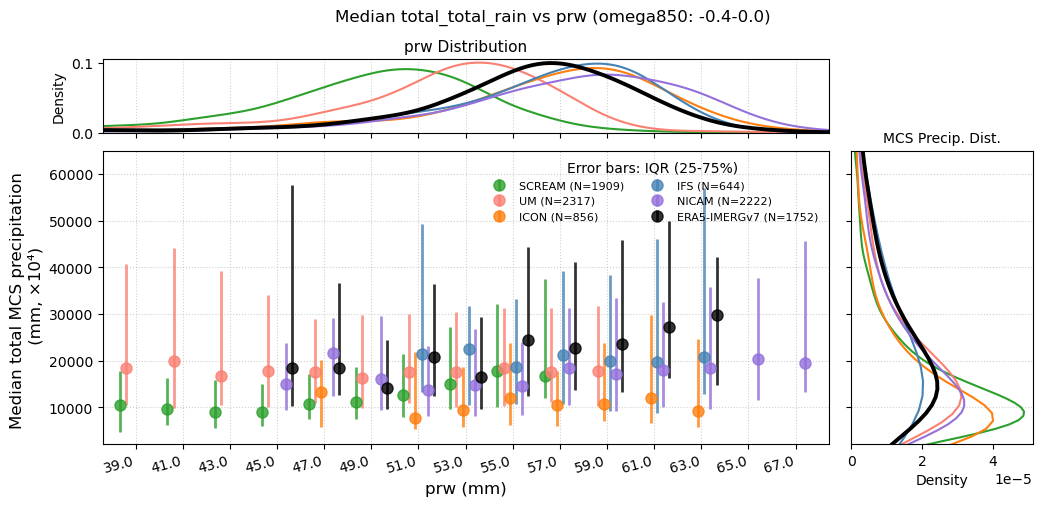

In [32]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='prw',
    bins=np.arange(38,70,2),
    constrain_var='omega850',
    manual_constrain_limits=(-.4,0),  # common omegas
    stat='median',legend_fontsize=8, 
    error_type='iqr',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=15, #xmin=7.5/1000,xmax=15.5/1000,
    xaxis_multiplier=1,  
    xaxis_units='mm',       # Show units
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2222 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2598: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


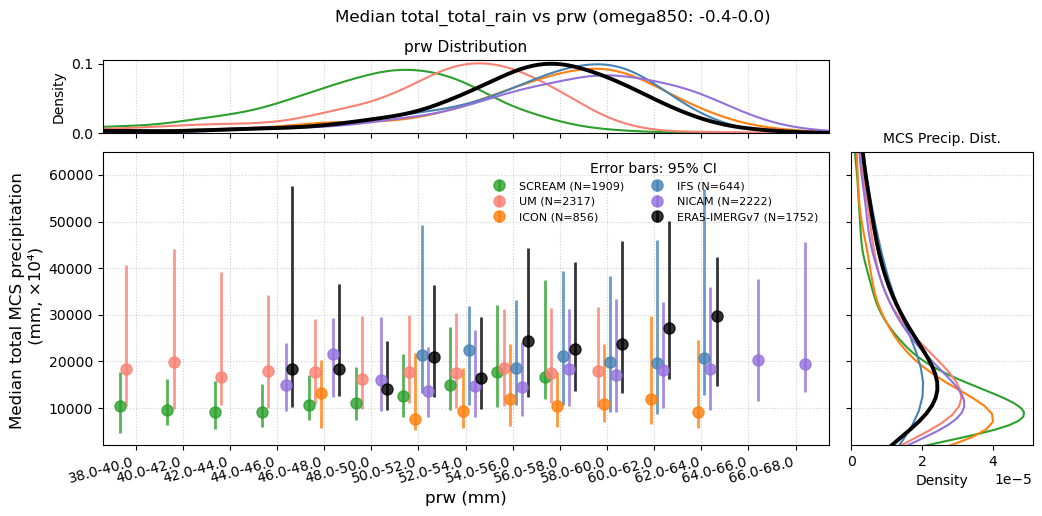

In [28]:
# sin logscale

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2369 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2496: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


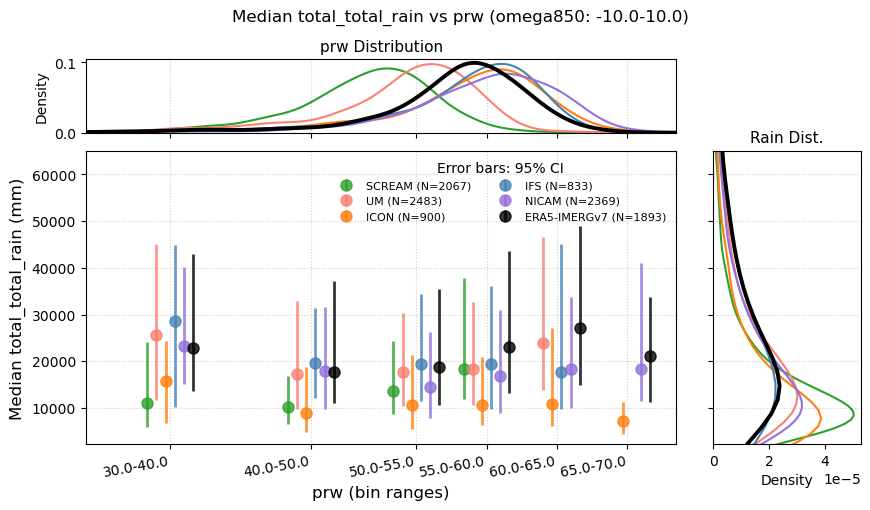

In [101]:
# Example 2: PRW bins with omega850 constraint (auto overlap)
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='prw',
    bins=[30,40,50,55,60,65,70,],
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # ALL OMEGA
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,
    figsize=(10, 5),ymax=65000,show_bin_separators=False
)

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2370 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


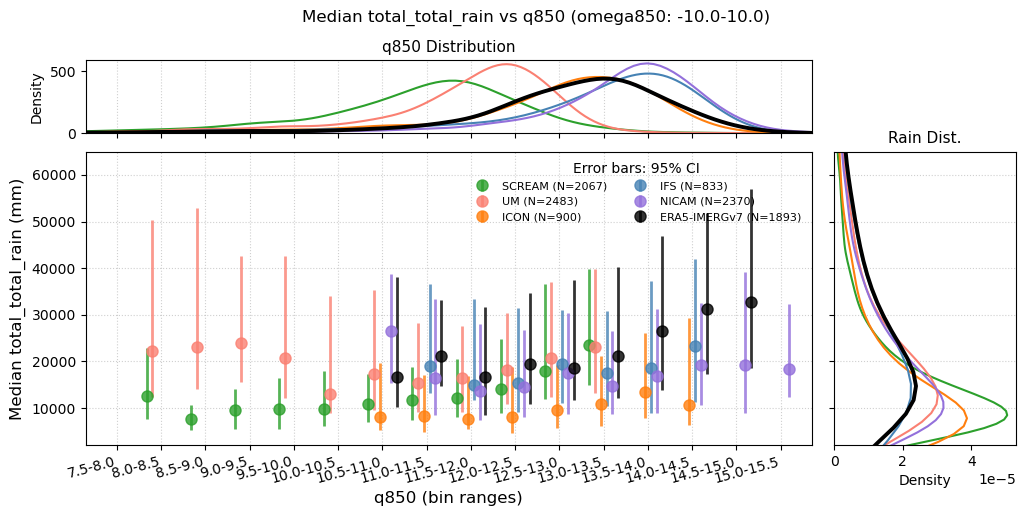

In [154]:
# Example 2: PRW bins with omega850 constraint (auto overlap)
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(7.5/1000,16/1000,.5/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=15,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg'      # Show units
)

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2370 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


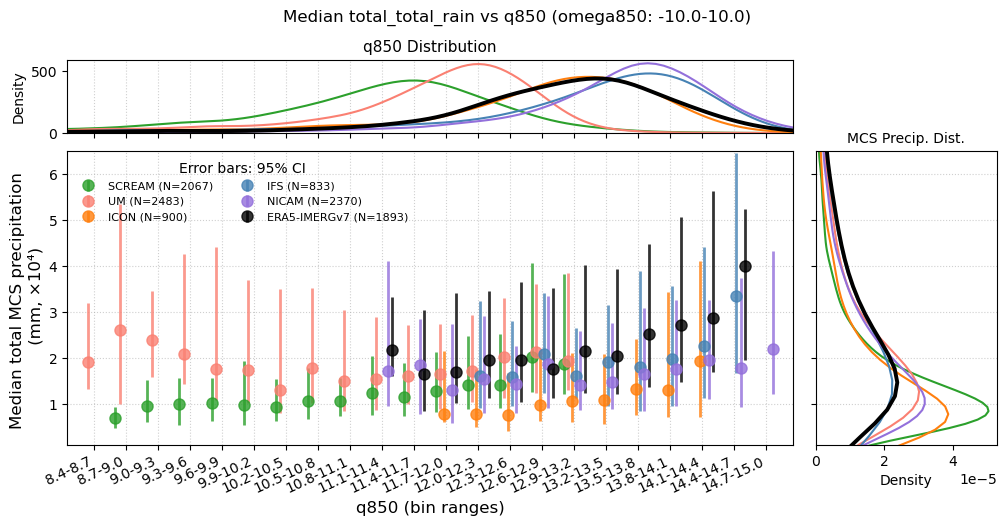

In [177]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(7.5/1000,16/1000,.3/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=25,xmax=15.1/1000,xmin=8.3/1000,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg'      # Show units
)
#    bins=np.arange(7.5/1000,16/1000,.3/1000),
#   figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=20,xmax=15.8/1000,xmin=7.7/1000,

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2370 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2597: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


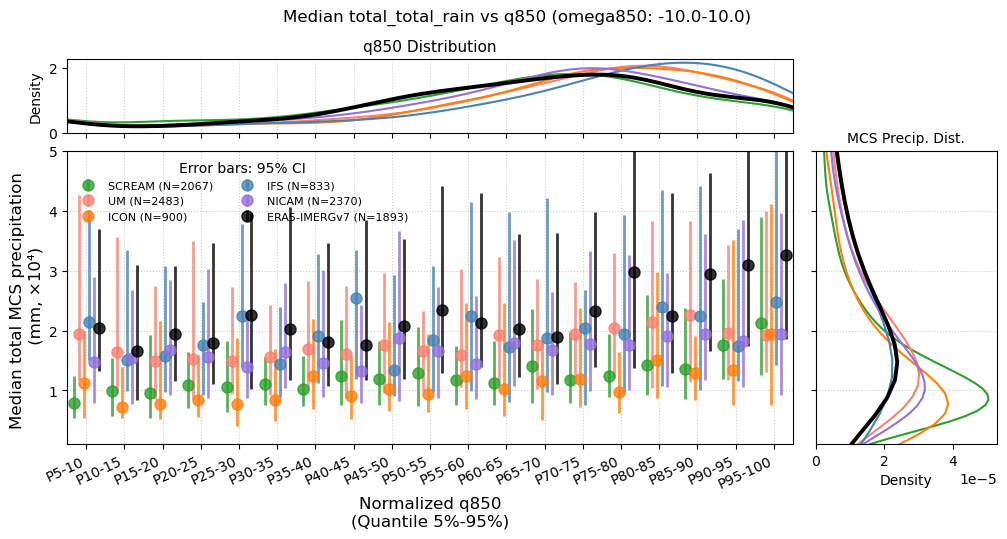

In [211]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    n_bins=20, normalize=True, use_quantile_norm=True, normalize_y=False,
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),show_bin_separators=False,rot=25,ymax=5e4,xmin=0.05, xmax=1,
    legend_loc="upper left"
)

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2370 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2598: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


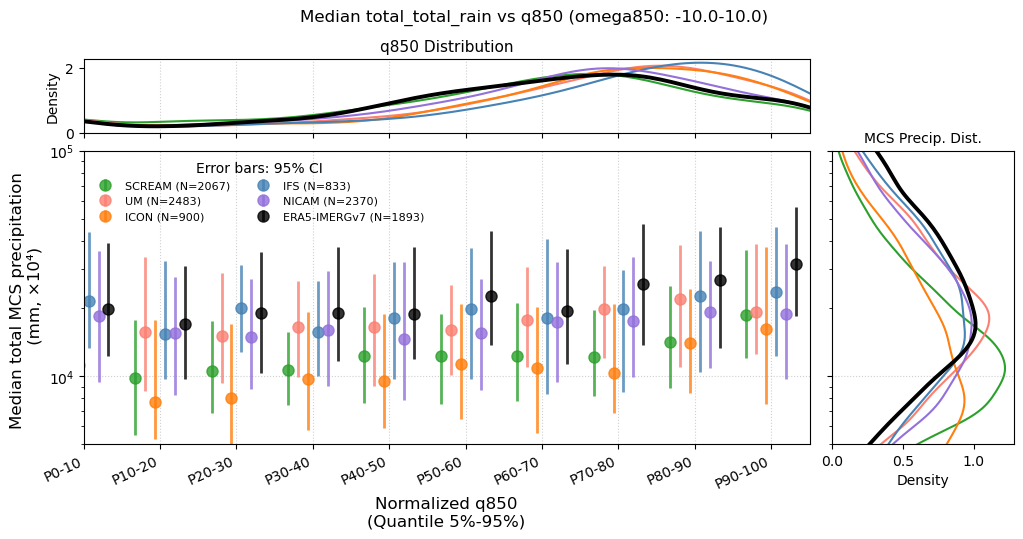

In [220]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    n_bins=10, normalize=True, use_quantile_norm=True, normalize_y=False,
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),show_bin_separators=False,rot=25,ymin= 0.5e4,ymax=10e4,xmin=0.05, xmax=1,
    legend_loc="upper left"
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2223 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2516: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


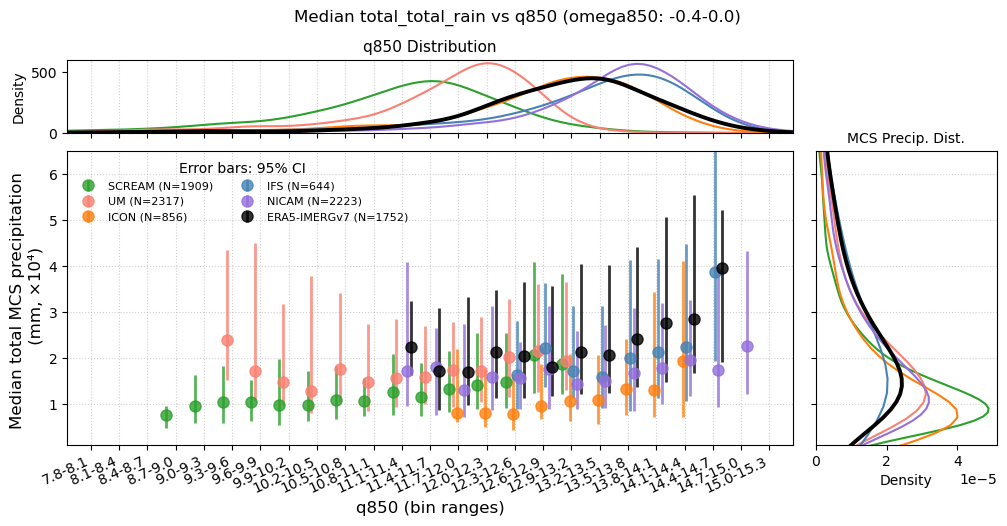

In [165]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(7.5/1000,16/1000,.3/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-.4,0),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=25,xmax=15.4/1000,xmin=7.7/1000,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg',      # Show units
    legend_loc='upper left',
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2223 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2597: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


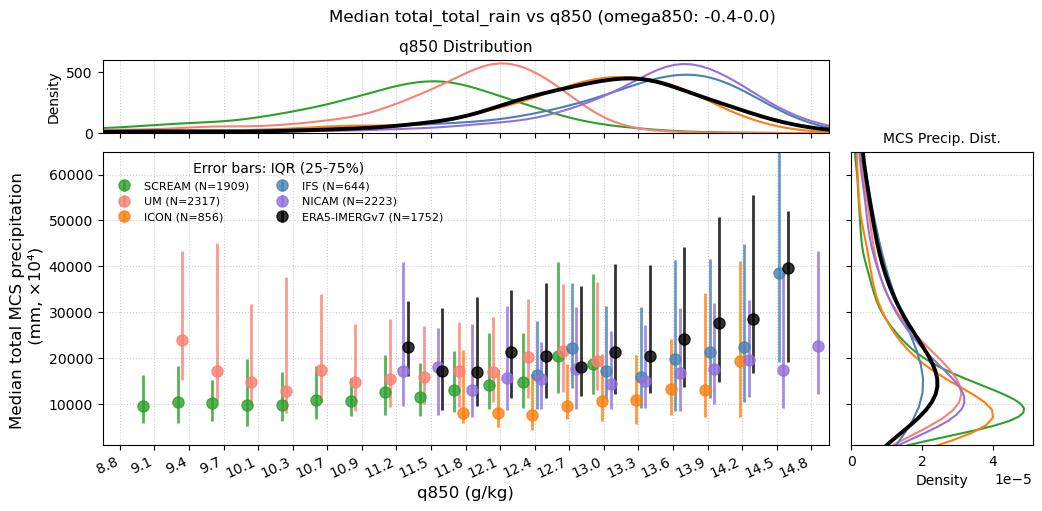

In [44]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(8.7/1000,15/1000,.3/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-.4,0),  # vertical ascent
    stat='median',legend_fontsize=8, 
    error_type='iqr',MODEL_STYLES=MODEL_STYLES,min_samples_per_bin=25,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,rot=25,xmax=15/1000,xmin=8.7/1000,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg',      # Show units
    legend_loc='upper left',
)

Using manual omega850 range: -10.00 - 10.00
SCREAM: 2067 samples in omega850 range
UM: 2483 samples in omega850 range
ICON: 900 samples in omega850 range
IFS: 833 samples in omega850 range
NICAM: 2370 samples in omega850 range
ERA5-IMERGv7: 1893 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


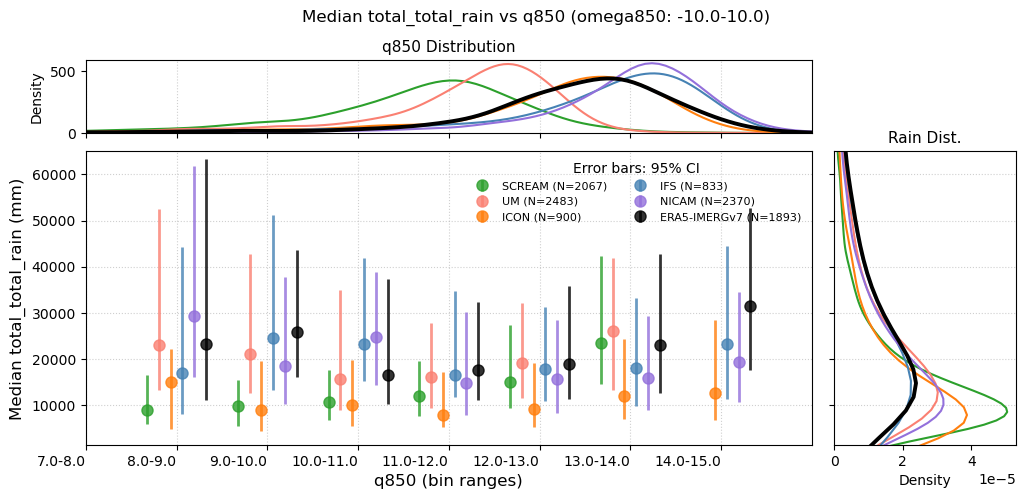

In [136]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(7/1000,16/1000,1/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-10,10),  # all omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,xmin=7.5/1000,xmax=15.5/1000,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg'      # Show units
)

Using manual omega850 range: -0.40 - 0.00
SCREAM: 1909 samples in omega850 range
UM: 2317 samples in omega850 range
ICON: 856 samples in omega850 range
IFS: 644 samples in omega850 range
NICAM: 2223 samples in omega850 range
ERA5-IMERGv7: 1752 samples in omega850 range


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis/tools_mcs_stats.py:2505: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


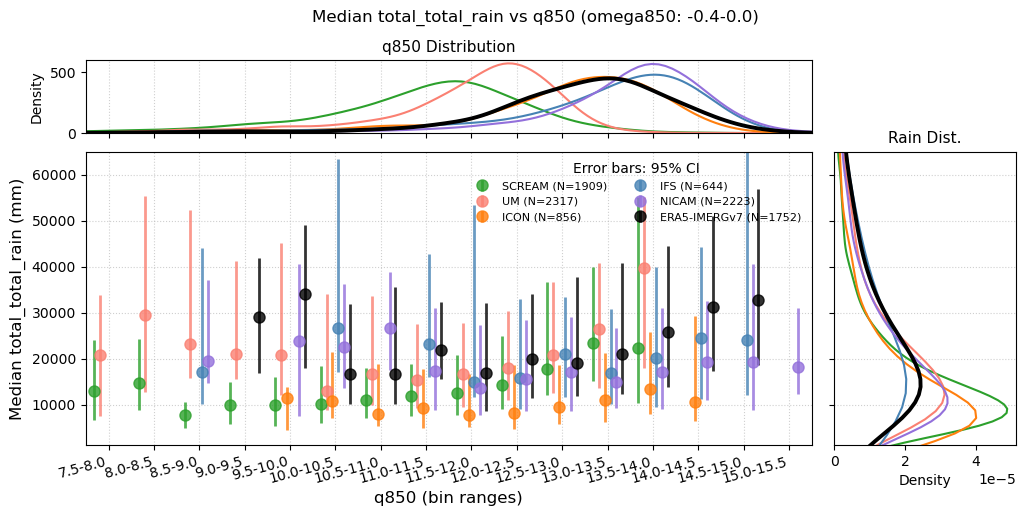

In [139]:
fig, df = tools_mcs_stats.plot_conditional_rain_distribution(
    processed_data,
    models=selected_models,
    crit='min2_longremoved',
    binned_var='q850',
    bins=np.arange(7/1000,16/1000,.5/1000),
    constrain_var='omega850',
    manual_constrain_limits=(-.4,0),  # common omegas
    stat='median',legend_fontsize=8, 
    error_type='ci95',MODEL_STYLES=MODEL_STYLES,
    figsize=(12, 5),ymax=65000,show_bin_separators=False,xmin=7.5/1000,xmax=15.5/1000,rot=15,
    xaxis_multiplier=1000,  # Convert kg/kg to g/kg
    xaxis_units='g/kg'      # Show units
)

Using manual lShear range: 0.00 - 5.00
Omega bins (raw quartiles): [47.01481198 49.97948422 52.05244549 53.66989517 55.14960861 56.49159927
 57.81093674 59.33437453 61.35047967 69.42240906]

=== Plotting omega distribution (top panel) ===
Total omega data points: 6779


/tmp/ipykernel_1333220/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


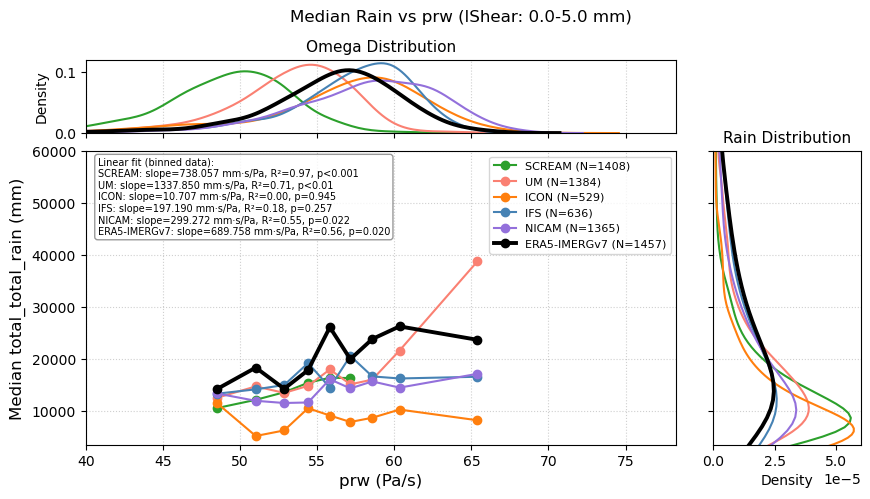

In [38]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [ 0.1, 0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, constrain_var='lShear',
    crit='min2_longremoved',omega_var='prw',
    manual_prw_limits=(0,5) , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmin=40,
    figsize=(10, 5)
)

Using manual lShear range: 3.00 - 5.00
Omega bins (raw quartiles): [0.01083979 0.01144923 0.01186703 0.01220885 0.01255496 0.0129324
 0.01332614 0.01365725 0.01404809 0.01603641]

=== Plotting omega distribution (top panel) ===
Total omega data points: 4266


/tmp/ipykernel_1333220/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


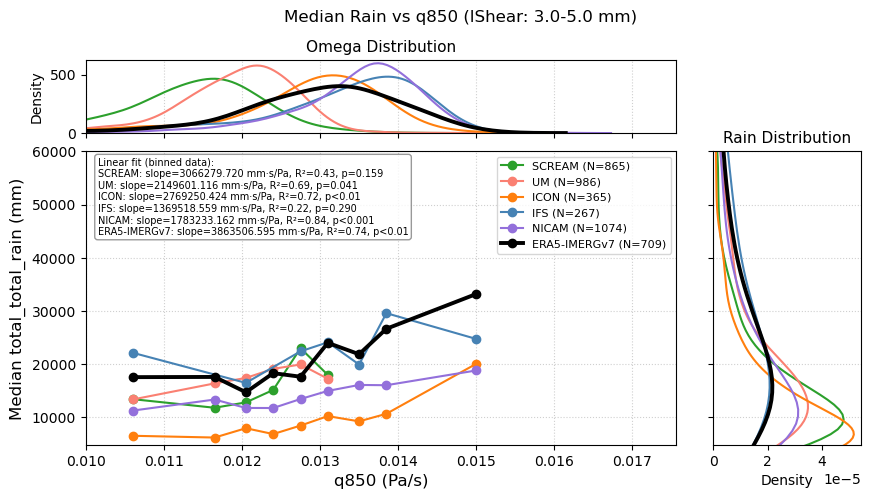

In [42]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [ 0.1, 0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, constrain_var='lShear',
    crit='min2_longremoved',omega_var='q850',
    manual_prw_limits=(3,5) , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmin=0.01,
    figsize=(10, 5)
)

Using manual omega850 range: -0.40 - 0.02
Omega bins (raw quartiles): [0.01053696 0.01135119 0.01181437 0.01216903 0.01251096 0.01289609
 0.01329537 0.01363881 0.01402302 0.01721412]

=== Plotting omega distribution (top panel) ===
Total omega data points: 9993


/tmp/ipykernel_1333220/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


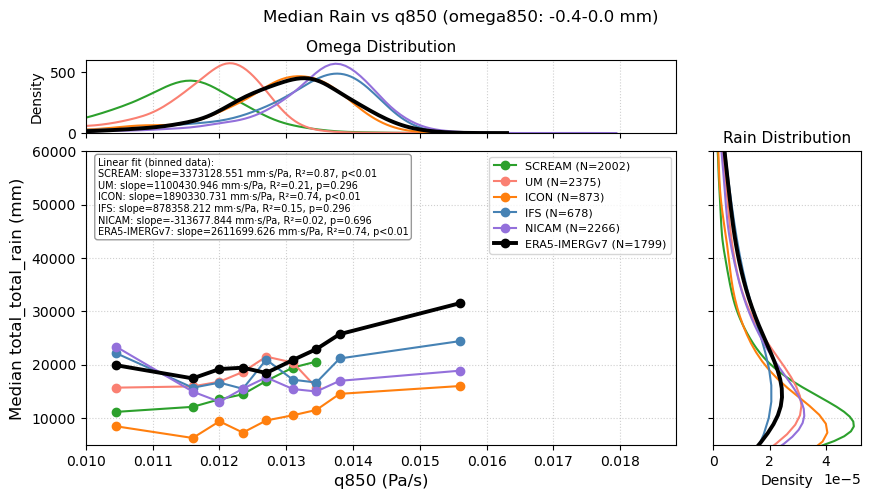

In [35]:
#omega limits =(-0.4,0.02) , #moisture var: q850

Using auto-calculated free_rh range: 61.07 - 67.60
Omega bins (raw quartiles): [-0.2006024  -0.15773174 -0.13382527 -0.11509241 -0.09644614 -0.08090295
 -0.06240103 -0.04201428 -0.01356449  0.12629615]

=== Plotting omega distribution (top panel) ===
Total omega data points: 1254


/tmp/ipykernel_1960480/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


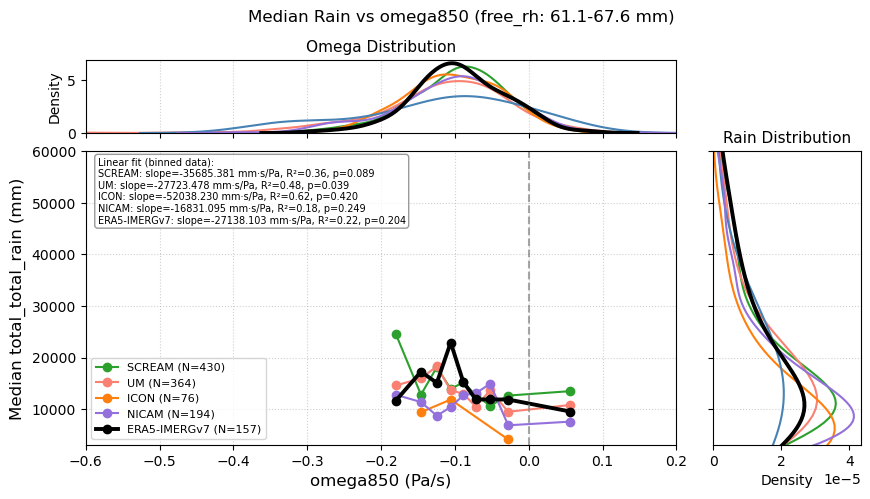

In [162]:
### constraining FREE RH

selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [ 0.1, 0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',constrain_var='free_rh',
    manual_prw_limits=None , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmax=0.2,xmin=-0.6,
    figsize=(10, 5)
)

Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.19432712 -0.16110544 -0.13577873 -0.11438525 -0.09517717
 -0.07461386 -0.05142473 -0.02015271  0.28470599]

=== Plotting omega distribution (top panel) ===
Total omega data points: 6513


/tmp/ipykernel_1960480/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


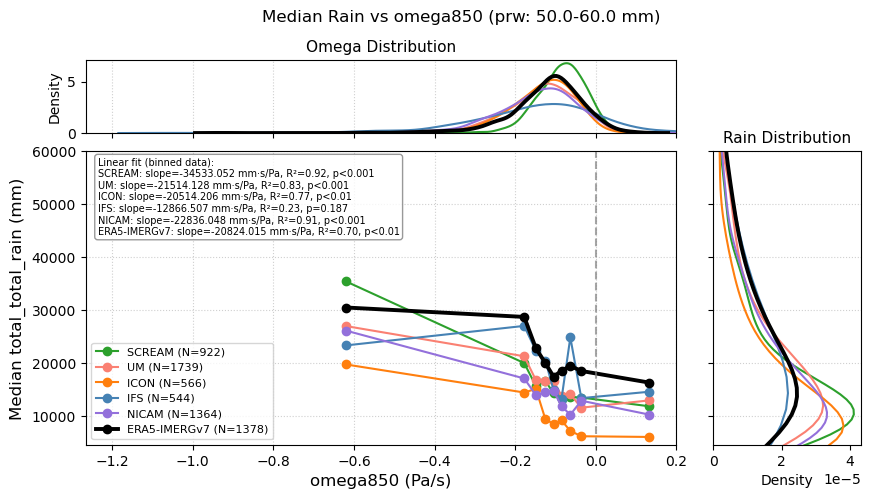

In [69]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [0, 0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmax=0.2,
    figsize=(10, 5)
)

Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-0.25015671 -0.19432712 -0.16110544 -0.13577873 -0.11438525 -0.09517717
 -0.07461386 -0.05142473 -0.02015271  0.28470599]

=== Plotting omega distribution (top panel) ===
Total omega data points: 6513


/tmp/ipykernel_1960480/1571370241.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


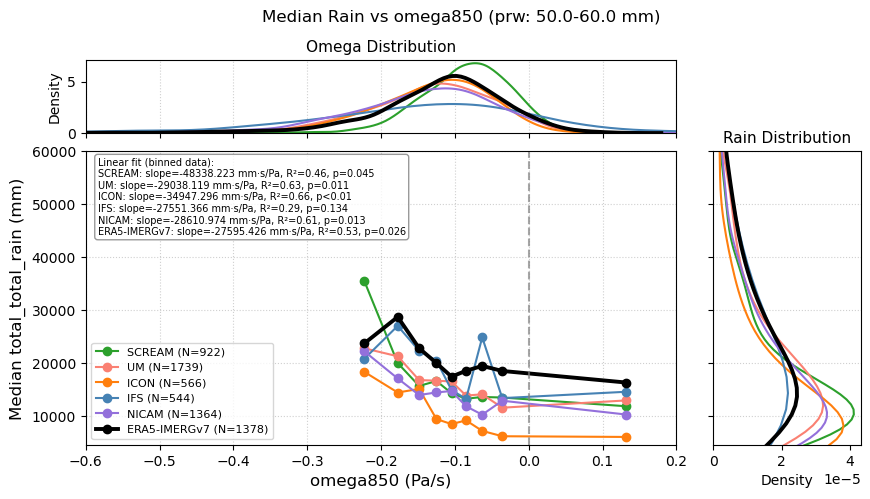

In [67]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam',  'obs_v7']
omega_qtiles = [ 0.1,0.2, 0.3, 0.4,0.5, 0.6,0.7, 0.8,0.9, 1.0] #np.arange(0,1,.1)
fig, df, reg_bin_stats = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) , omega_qtiles=omega_qtiles,
    stat='median',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=60000,xmax=0.2,xmin=-0.6,
    figsize=(10, 5)
)

Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.17621805 -0.11585291 -0.06514519  0.28470599]

=== Plotting omega distribution (top panel) ===
Total omega data points: 8344


/tmp/ipykernel_1960480/3810846610.py:457: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


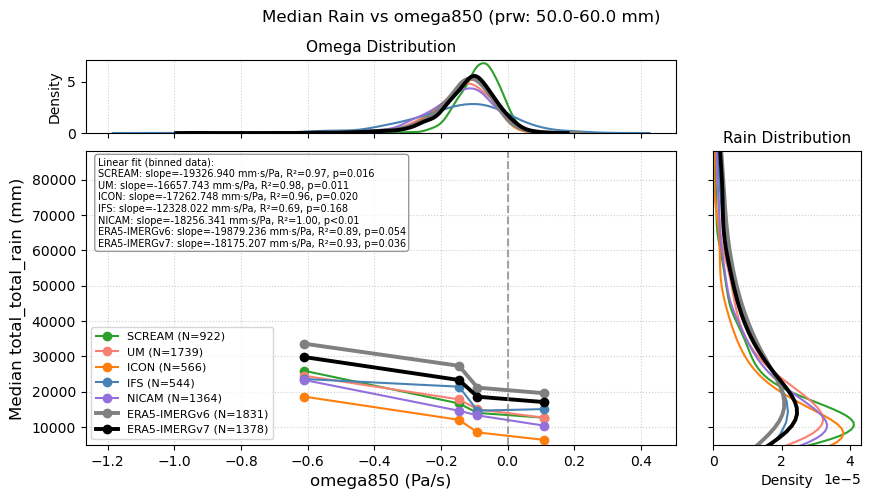

In [48]:
# Test with example 2 but adding debug output
  # Just one model for clarity




Using auto-calculated prw range: 46.49 - 52.86
Omega bins (raw quartiles): [-0.96303346 -0.15625162 -0.09941335 -0.05164005  0.21971578]

=== Plotting omega distribution (top panel) ===
Total omega data points: 3358


/tmp/ipykernel_1960480/3271288535.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


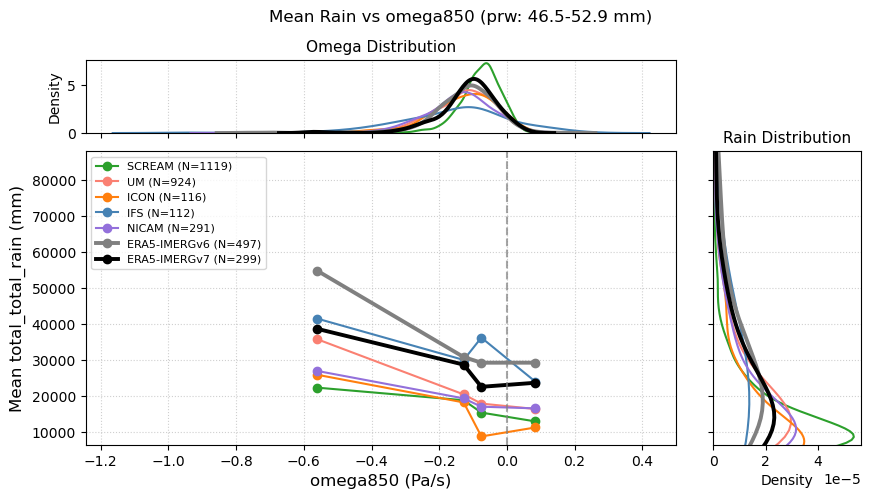

In [23]:
# Test with example 2 but adding debug output
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam', 'obs', 'obs_v7']  # Just one model for clarity
fig, df = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=None ,
    stat='mean',
    normalize=False,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=88000,
    figsize=(10, 5)
)


Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.17621805 -0.11585291 -0.06514519  0.28470599]

--- Normalization Ranges ---
  SCREAM: Rain [4892.52, 53369.93], Omega [-0.183, 0.004]
  UM: Rain [5211.59, 66650.45], Omega [-0.289, -0.003]
  ICON: Rain [3140.87, 53133.59], Omega [-0.290, -0.021]
  IFS: Rain [4441.74, 77651.14], Omega [-0.436, 0.072]
  NICAM: Rain [4127.96, 68964.48], Omega [-0.319, -0.001]
  ERA5-IMERGv6: Rain [7159.47, 108591.30], Omega [-0.285, -0.008]
  ERA5-IMERGv7: Rain [5836.79, 95311.79], Omega [-0.279, 0.004]

=== Plotting omega distribution (top panel) ===
Total omega data points: 8344


/tmp/ipykernel_2281439/2769201858.py:375: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


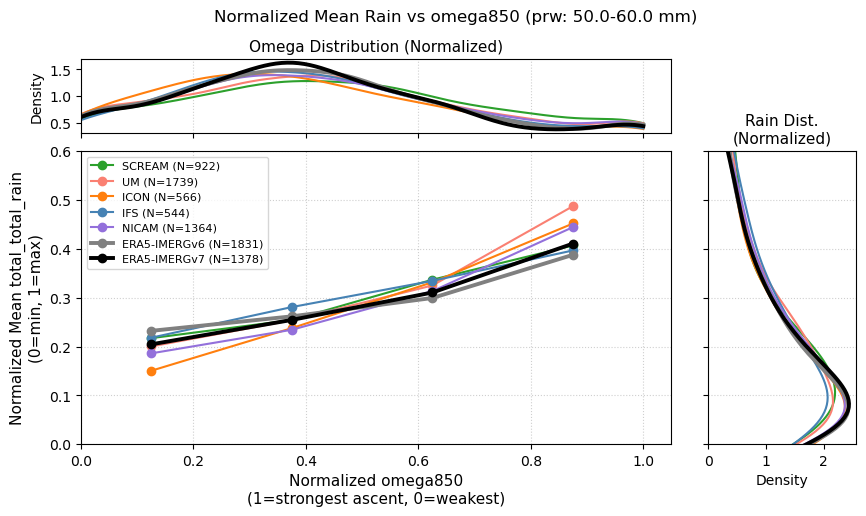

In [68]:
# Test with example 2 but adding debug output
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam', 'obs', 'obs_v7']  # Just one model for clarity
fig, df = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) ,
    stat='mean',
    normalize=True,  use_quantile_norm=True,lower_quantile=0.05,upper_quantile=0.95,
    min_samples_per_bin=20,  # Lower threshold for testing
    legend_fontsize=8,ymax=0.6,
    figsize=(10, 5)
)


Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-0.43619124 -0.17621805 -0.11585291 -0.06514519  0.07174614]

=== Plotting omega distribution (top panel) ===
Total omega data points: 8344


/tmp/ipykernel_2281439/3271288535.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


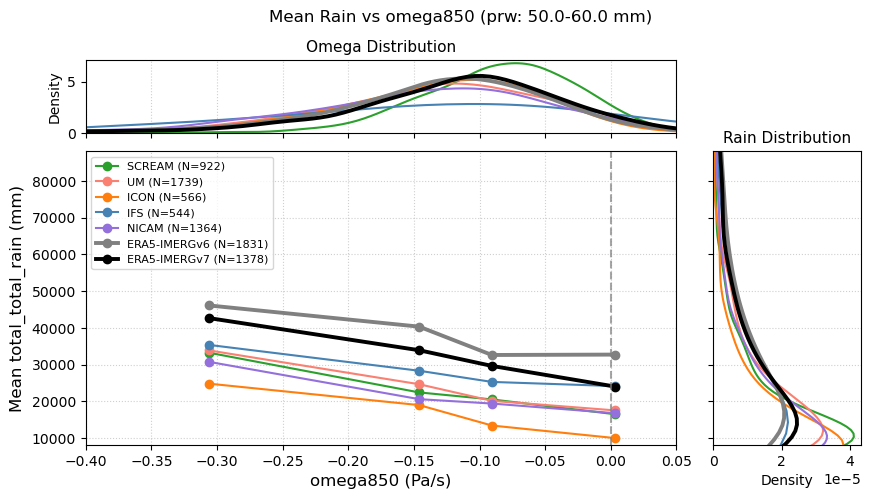

In [78]:
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam', 'obs', 'obs_v7']  # Just one model for clarity
fig, df_raw = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) ,
    stat='mean',
    normalize=False,  use_quantile_norm=True,lower_quantile=0.05,upper_quantile=0.95,
    clip_bins_to_quantiles=True,
    min_samples_per_bin=20,  # Lower threshold for testing
    legend_fontsize=8,ymax=88000,xmin=-.4,xmax=.05,
    figsize=(10, 5)
)


In [71]:
# Check if omega extremes coincide with rain extremes
models_to_check = ['obs', 'obs_v7', 'scream']
crit = 'min2_longremoved'
prw_limits = (50, 60)
extreme_quantile = 0.05

print("="*80)
print("DO OMEGA EXTREMES COINCIDE WITH RAIN EXTREMES?")
print("="*80)

for model in models_to_check:
    # Get data
    df_c = processed_data[model][crit]['prw']
    df_x = processed_data[model][crit]['omega850']
    f_c = df_c[(df_c.radius == 2) & (df_c.time_offset_hours == 0)]
    f_x = df_x[(df_x.radius == 2) & (df_x.time_offset_hours == 0)]
    merged = pd.merge(f_c[['track_id', 'mean', 'total_total_rain']], 
                     f_x[['track_id', 'mean']], 
                     on='track_id', suffixes=('_prw', '_omega'))
    subset = merged[(merged['mean_prw'] >= prw_limits[0]) & 
                    (merged['mean_prw'] <= prw_limits[1])].copy()
    
    # Identify extremes
    omega_low = subset['mean_omega'].quantile(extreme_quantile)
    omega_high = subset['mean_omega'].quantile(1 - extreme_quantile)
    rain_low = subset['total_total_rain'].quantile(extreme_quantile)
    rain_high = subset['total_total_rain'].quantile(1 - extreme_quantile)
    
    # Flag extreme cases
    omega_extreme = (subset['mean_omega'] < omega_low) | (subset['mean_omega'] > omega_high)
    rain_extreme = (subset['total_total_rain'] < rain_low) | (subset['total_total_rain'] > rain_high)
    
    # Calculate overlap
    both_extreme = omega_extreme & rain_extreme
    only_omega = omega_extreme & ~rain_extreme
    only_rain = rain_extreme & ~omega_extreme
    neither = ~omega_extreme & ~rain_extreme
    
    print(f"\n{MODEL_STYLES[model]['label']} (N={len(subset)}):")
    print(f"  Omega extremes: {omega_extreme.sum()} ({omega_extreme.sum()/len(subset)*100:.1f}%)")
    print(f"  Rain extremes:  {rain_extreme.sum()} ({rain_extreme.sum()/len(subset)*100:.1f}%)")
    print(f"  Both extreme:   {both_extreme.sum()} ({both_extreme.sum()/len(subset)*100:.1f}%)")
    print(f"  Only omega:     {only_omega.sum()} ({only_omega.sum()/len(subset)*100:.1f}%)")
    print(f"  Only rain:      {only_rain.sum()} ({only_rain.sum()/len(subset)*100:.1f}%)")
    print(f"  Neither:        {neither.sum()} ({neither.sum()/len(subset)*100:.1f}%)")
    
    # Correlation between omega and rain
    corr = subset['mean_omega'].corr(subset['total_total_rain'])
    print(f"  Omega-Rain correlation: {corr:.3f}")
    
    # Check if extreme omega → extreme rain
    if omega_extreme.sum() > 0:
        mean_rain_omega_extreme = subset[omega_extreme]['total_total_rain'].mean()
        mean_rain_normal = subset[~omega_extreme]['total_total_rain'].mean()
        print(f"  Mean rain (omega extreme): {mean_rain_omega_extreme:.1f} mm")
        print(f"  Mean rain (omega normal):  {mean_rain_normal:.1f} mm")

DO OMEGA EXTREMES COINCIDE WITH RAIN EXTREMES?

ERA5-IMERGv6 (N=1831):
  Omega extremes: 184 (10.0%)
  Rain extremes:  184 (10.0%)
  Both extreme:   28 (1.5%)
  Only omega:     156 (8.5%)
  Only rain:      156 (8.5%)
  Neither:        1491 (81.4%)
  Omega-Rain correlation: -0.165
  Mean rain (omega extreme): 44363.7 mm
  Mean rain (omega normal):  37528.1 mm

ERA5-IMERGv7 (N=1378):
  Omega extremes: 138 (10.0%)
  Rain extremes:  138 (10.0%)
  Both extreme:   23 (1.7%)
  Only omega:     115 (8.3%)
  Only rain:      115 (8.3%)
  Neither:        1125 (81.6%)
  Omega-Rain correlation: -0.242
  Mean rain (omega extreme): 39912.5 mm
  Mean rain (omega normal):  31285.1 mm

SCREAM (N=922):
  Omega extremes: 94 (10.2%)
  Rain extremes:  94 (10.2%)
  Both extreme:   10 (1.1%)
  Only omega:     84 (9.1%)
  Only rain:      84 (9.1%)
  Neither:        744 (80.7%)
  Omega-Rain correlation: -0.249
  Mean rain (omega extreme): 24770.8 mm
  Mean rain (omega normal):  19627.7 mm


Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.17621805 -0.11585291 -0.06514519  0.28470599]

--- Normalization Ranges ---
  SCREAM: Rain [1932.15, 163245.22], Omega [-0.379, 0.076]
  UM: Rain [1435.59, 214436.64], Omega [-0.595, 0.169]
  ICON: Rain [1563.12, 220188.94], Omega [-0.738, 0.113]
  IFS: Rain [2654.50, 548844.31], Omega [-1.044, 0.285]
  NICAM: Rain [919.62, 163535.50], Omega [-0.676, 0.137]
  ERA5-IMERGv6: Rain [3006.07, 334344.00], Omega [-0.646, 0.160]
  ERA5-IMERGv7: Rain [2275.16, 293052.50], Omega [-0.929, 0.115]

=== Plotting omega distribution (top panel) ===
Total omega data points: 8344


/tmp/ipykernel_238114/2561607120.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


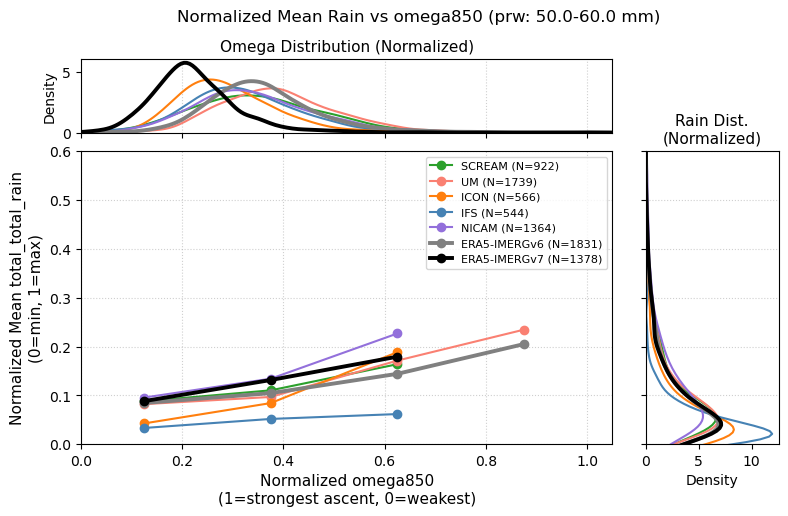

In [68]:
# Test with example 2 but adding debug output
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam', 'obs', 'obs_v7']  # Just one model for clarity
fig, df = plot_mean_rain_vs_binned_omega(   
    processed_data,  
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) ,
    stat='mean',
    normalize=True,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=8,ymax=.6,
    figsize=(9, 5)
)


Using manual prw range: 50.00 - 60.00
Omega bins (raw quartiles): [-1.04403099 -0.17621805 -0.11585291 -0.06514519  0.28470599]

--- Normalization Ranges ---
  SCREAM: Rain [1932.15, 163245.22], Omega [-0.379, 0.076]
  UM: Rain [1435.59, 214436.64], Omega [-0.595, 0.169]
  ICON: Rain [1563.12, 220188.94], Omega [-0.738, 0.113]
  IFS: Rain [2654.50, 548844.31], Omega [-1.044, 0.285]
  NICAM: Rain [919.62, 163535.50], Omega [-0.676, 0.137]
  ERA5-IMERGv6: Rain [3006.07, 334344.00], Omega [-0.646, 0.160]
  ERA5-IMERGv7: Rain [2275.16, 293052.50], Omega [-0.929, 0.115]


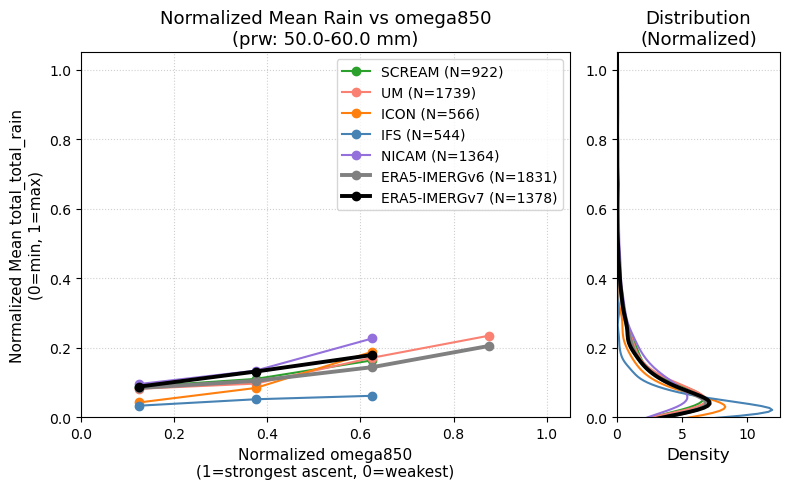

In [54]:
# Test with example 2 but adding debug output
selected_models = ['scream', 'um', 'icon', 'ifs', 'nicam', 'obs', 'obs_v7']  # Just one model for clarity
fig, df = plot_mean_rain_vs_binned_omega(
    processed_data, 
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=(50,60) ,
    stat='mean',
    normalize=True,  
    min_samples_per_bin=10,  # Lower threshold for testing
    legend_fontsize=10,
    figsize=(8, 5)
)


Using auto-calculated prw range: 46.49 - 52.86
Omega bins (quartiles): [-0.96303346 -0.23061954 -0.15625162 -0.09941335 -0.05164005 -0.01386709
  0.21971578]


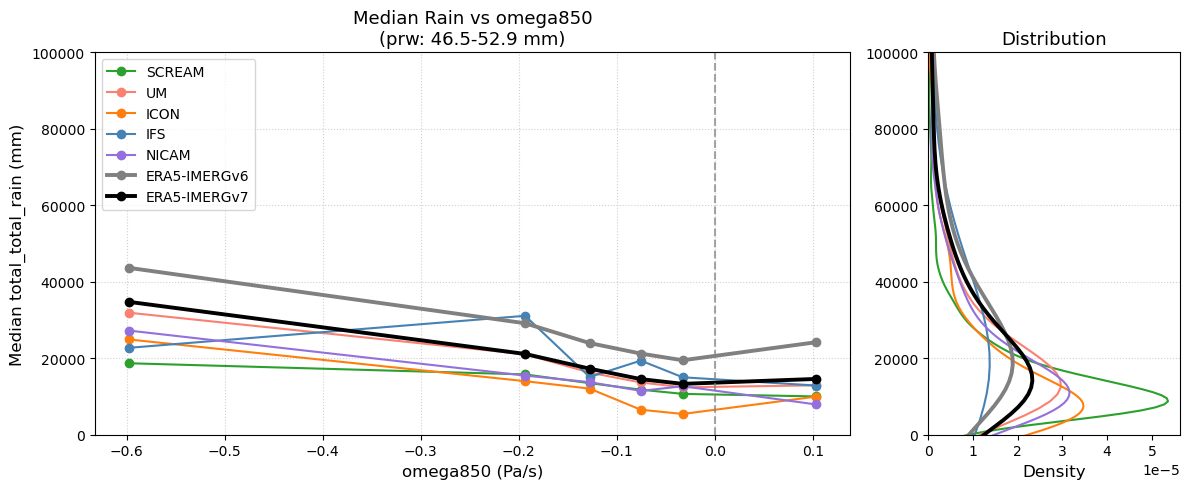

In [ ]:
# Example 1: Using auto-calculated PRW overlap (non-normalized)
selected_models = ['icon', 'ifs', 'nicam']
fig, df = plot_mean_rain_vs_binned_omega(
    processed_data, 
    selected_models, 
    crit='min2_longremoved',
    manual_prw_limits=None,  # Auto-calculate overlap
    stat='mean',
    normalize=False,  # Show raw values
    min_samples_per_bin=10,  # Filter bins with < 10 samples
    legend_fontsize=10,
    figsize=(12, 5)
)


In [53]:
def plot_rain_vs_omega_constrained(data_dict, models, crit='all', 
                                   constrain_var='prw', 
                                   x_var='omega850', 
                                   y_var='total_total_rain',  radius=2, time=0):
    
    # 1. Get constraint range (Intersection of 10th-90th percentiles)
    overlap, _ = get_common_overlap(data_dict, models, crit=crit, var=constrain_var)
    if not overlap: return

    plot_data = []

    for model in models:
        # We need to merge the Constrain Var DF and the X Var DF
        # Assuming they share 'track_id', 'radius', 'time_offset_hours'
        
        df_constrain = data_dict[model][crit][constrain_var]
        df_x = data_dict[model][crit][x_var]
        
        # Merge on index or common columns. 
        # Crucial: Ensure 'radius' and 'time' are filtered BEFORE merge to avoid duplicates
        # or merge on them too.
        
        # Simple approach: Filter both first
        f_c = df_constrain[(df_constrain.radius==radius) & (df_constrain.time_offset_hours==time)]
        f_x = df_x[(df_x.radius==radius) & (df_x.time_offset_hours==time)]
        
        # Merge. We need 'track_id' to match the exact same storm event
        merged = pd.merge(f_c[['track_id', 'mean', y_var]], 
                          f_x[['track_id', 'mean']], 
                          on='track_id', suffixes=('_constrain', '_x'))
        
        # Filter by Constraint (e.g., PRW between 50 and 55)
        filtered = merged[
            (merged['mean_constrain'] >= overlap[0]) & 
            (merged['mean_constrain'] <= overlap[1])
        ].copy()
        
        filtered['Model'] = MODEL_STYLES[model]['label']
        plot_data.append(filtered)

    full_df = pd.concat(plot_data)

    # 2. Bin the X-variable (Omega)
    # create 10 bins for Omega
    full_df['omega_bin'] = pd.cut(full_df['mean_x'], bins=10)

    # 3. Plot
    plt.figure(figsize=(12, 6))
    
    # Boxplot: X=Omega Bin, Y=Rain, Hue=Model
    sns.boxplot(data=full_df, x='omega_bin', y=y_var, hue='Model', 
                palette={v['label']: v['color'] for k,v in MODEL_STYLES.items() if k in models},
                showfliers=False) # Hide outliers to see the distribution box better
    
    plt.title(f"Rain vs Omega850 (Constrained: {overlap[0]:.1f} < {constrain_var} < {overlap[1]:.1f})")
    plt.xticks(rotation=45)
    plt.xlabel("Omega 850hPa Bins (Pa/s)")
    plt.ylabel("Total Rainfall Distribution")
    plt.show()

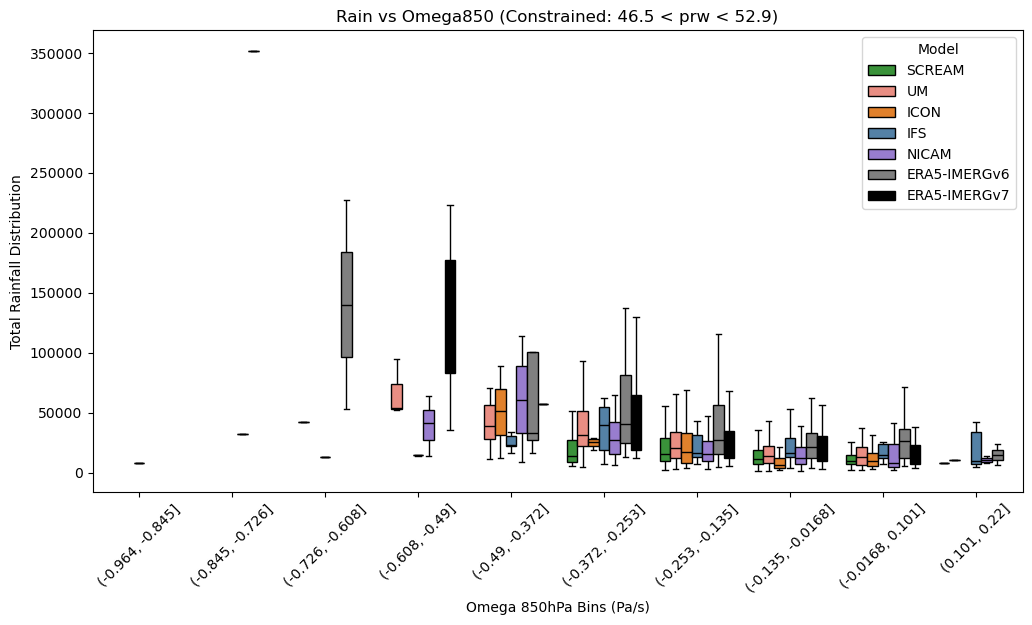

In [54]:
selected_models = ['scream','um','icon', 'ifs',  'nicam','obs','obs_v7',] 

plot_rain_vs_omega_constrained(processed_data, selected_models, 
    crit='min2_longremoved',  constrain_var='prw',  x_var='omega850', y_var='total_total_rain')